# Problem

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import random
import torch
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors

# This starts from the current working directory
# and goes up until it finds the 'fogas_torch' folder or '.git'
def find_root(current_path, marker="fogas_torch"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
print(f"Project root found at: {PROJECT_ROOT}")

# Add project root to sys.path so we can import local packages
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
# Now define the dataset path
DATASET_PATH = PROJECT_ROOT / "datasets" / "10grid_exp.csv"
DATASET_PATH1 = PROJECT_ROOT / "datasets" / "20grid.csv"
print(f"Loading dataset from: {DATASET_PATH}")

from fogas_torch import PolicySolver, EnvDataCollector
from fogas_torch.algorithm import (
    FOGASSolverVectorized,
    FOGASOracleSolverVectorized,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
)
from fogas_torch.dataset_collection import DatasetAnalyzer
from fogas_torch.fqi.fqi_solver import FQISolver
from fogas_torch.fqi.fqi_evaluator import FQIEvaluator

seed = 44
np.random.seed(seed) # Add this
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Project root found at: /shared/home/mauro.diaz/work/FOGAS
Loading dataset from: /shared/home/mauro.diaz/work/FOGAS/datasets/10grid_exp.csv
Using device: cuda


# Problem

### Scaling

In [2]:
def scale_grid(small_grid, factor=2):
    """
    Refine each coarse cell into a factor x factor block.
    Keep a single S and G at the scaled positions of the original ones.
    """
    large_grid = np.repeat(np.repeat(small_grid, factor, axis=0), factor, axis=1)

    # Find original S and G
    s_pos = np.argwhere(small_grid == 'S')[0]
    g_pos = np.argwhere(small_grid == 'G')[0]

    # Remove duplicated S/G blocks
    large_grid[large_grid == 'S'] = '.'
    large_grid[large_grid == 'G'] = '.'

    # Put one unique S/G at scaled coordinates
    s_big = tuple((s_pos * factor).tolist())
    g_big = tuple((g_pos * factor + (factor - 1)).tolist())  # choose bottom-right of block for G

    large_grid[s_big] = 'S'
    large_grid[g_big] = 'G'

    return large_grid

def scale_grid_goal_block(small_grid, factor=2):
    """
    Refine each coarse cell into a factor x factor block.
    Keep a single S, but expand G to the full factor x factor block.
    """
    large_grid = np.repeat(np.repeat(small_grid, factor, axis=0), factor, axis=1)

    s_pos = np.argwhere(small_grid == 'S')[0]
    g_pos = np.argwhere(small_grid == 'G')[0]

    # Remove duplicated start block only
    large_grid[large_grid == 'S'] = '.'

    # Reinsert one unique start at the top-left of the scaled start block
    s_big = tuple((s_pos * factor).tolist())
    large_grid[s_big] = 'S'

    # Expand the goal to the full fine block
    g_r, g_c = (g_pos * factor).tolist()
    large_grid[g_r:g_r + factor, g_c:g_c + factor] = 'G'

    return large_grid


### Plotting methods

In [3]:
def plot_fogas_grid(grid_data):
    """
    Visualizes large grids (50x50, 100x100) for RL analysis.
    """
    size = grid_data.shape[0]
    
    # Mapping characters to numeric values for plotting
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    # Define a high-contrast color palette
    # Empty (White), Wall (Black), Pit (Red), Start (Blue), Goal (Green)
    colors = ['#FFFFFF', '#333333', '#FF0000', '#0000FF', '#00FF00']
    cmap = mcolors.ListedColormap(colors)
    
    # Set plot size to fit comfortably in a notebook
    plt.figure(figsize=(10, 10))
    plt.imshow(numeric_grid, cmap=cmap)
    
    # Grid lines to help distinguish cells in 50x50
    if size <= 50:
        plt.grid(which='both', color='grey', linestyle='-', linewidth=0.5, alpha=0.3)
        plt.xticks(np.arange(-0.5, size, 5), [])
        plt.yticks(np.arange(-0.5, size, 5), [])
    
    plt.title(f"FOGAS Environment: {size}x{size} Grid", fontsize=15)
    
    # Legend construction
    patches = [
        plt.plot([],[], marker="s", ms=10, ls="", color=colors[i], 
                 label=list(mapping.keys())[i])[0]  for i in range(len(colors))
    ]
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    plt.tight_layout()
    plt.show()
    
def compute_optimal_path(mdp, mdp_data, size, max_steps=1000):
    """
    Computes the optimal path from start to goal by following mdp.pi_star 
    and looking up the resulting state in the transition matrix mdp.P.
    """
    current_state = mdp_data["start"]
    goal_state = mdp_data["goal"]
    pits = mdp_data["pits"]
    path = []
    
    for _ in range(max_steps):
        # Convert 1D state index back to 2D (row, col) coordinates
        r, c = divmod(current_state, size)
        path.append((r, c))
        
        # Stop condition: Reached the goal or fell into a pit
        if current_state == goal_state or current_state in pits:
            break
            
        # Extract the optimal action index from the pi_star vector at the current state
        best_a = torch.argmax(mdp.pi_star[current_state]).item()
        
        # Find the next state from the MDP transition matrix P
        # P has shape (N*A, N). The row index is: state * total_actions + action
        next_state = torch.argmax(mdp.P[current_state * mdp.A + best_a]).item()
        
        # Failsafe to prevent getting stuck in a loop against a wall
        if next_state == current_state:
            break
            
        current_state = next_state
        
    return path


def sample_policy_path(mdp, mdp_data, size, pi=None, max_steps=1000, rng=None):
    """
    Sample one trajectory from a policy pi.

    Args:
        mdp: PolicySolver / MDP object
        mdp_data: dict with keys 'start', 'goal', 'pits'
        size: grid side length
        pi: tensor of shape (N, A). If None, uses mdp.pi_star
        max_steps: safety limit
        rng: numpy random generator (optional)

    Returns:
        path: list of (row, col)
        states: list of visited state indices
        actions: list of sampled action indices
    """
    if pi is None:
        pi = mdp.pi_star

    if rng is None:
        rng = np.random.default_rng()

    current_state = mdp_data["start"]
    goal_state = mdp_data["goal"]
    pits = set(mdp_data["pits"])

    path = []
    states = []
    actions = []

    for _ in range(max_steps):
        r, c = divmod(current_state, size)
        path.append((r, c))
        states.append(current_state)

        if current_state == goal_state or current_state in pits:
            break

        action_probs = pi[current_state].detach().cpu().numpy()
        action_probs = action_probs / action_probs.sum()

        a = rng.choice(mdp.A, p=action_probs)
        actions.append(int(a))

        transition_probs = mdp.P[current_state * mdp.A + a].detach().cpu().numpy()
        next_state = rng.choice(mdp.N, p=transition_probs)

        if next_state == current_state:
            break

        current_state = int(next_state)

    return path, states, actions

def sample_multiple_policy_paths(mdp, mdp_data, size, pi=None, n_paths=20, max_steps=1000, seed=None):
    """
    Sample multiple trajectories from a policy.

    Returns:
        paths: list of paths, each path is a list of (row, col)
        states_list: list of state-index trajectories
        actions_list: list of action-index trajectories
    """
    rng = np.random.default_rng(seed)

    paths = []
    states_list = []
    actions_list = []

    for _ in range(n_paths):
        path, states, actions = sample_policy_path(
            mdp=mdp,
            mdp_data=mdp_data,
            size=size,
            pi=pi,
            max_steps=max_steps,
            rng=rng
        )
        paths.append(path)
        states_list.append(states)
        actions_list.append(actions)

    return paths, states_list, actions_list

def unique_paths(paths):
    """
    Remove duplicate paths while preserving order.

    Args:
        paths: list of paths, where each path is a list of (row, col)

    Returns:
        unique: list of unique paths
    """
    seen = set()
    unique = []

    for path in paths:
        key = tuple(path)
        if key not in seen:
            seen.add(key)
            unique.append(path)

    return unique

def sample_unique_policy_paths(mdp, mdp_data, size, pi=None, n_samples=200, max_unique=10, max_steps=1000, seed=None):
    """
    Sample many trajectories and keep up to max_unique distinct ones.
    """
    paths, _, _ = sample_multiple_policy_paths(
        mdp=mdp,
        mdp_data=mdp_data,
        size=size,
        pi=pi,
        n_paths=n_samples,
        max_steps=max_steps,
        seed=seed
    )

    uniq = unique_paths(paths)
    return uniq[:max_unique]

def plot_agent_paths_with_labels(grid_data, paths, labels=None, title_suffix="", alpha=0.75):
    """
    Overlay trajectories on the grid.
    """
    size = grid_data.shape[0]
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    colors = ['#FFFFFF', '#333333', '#FF0000', '#0000FF', '#00FF00']
    cmap = mcolors.ListedColormap(colors)

    plt.figure(figsize=(10, 10))
    plt.imshow(numeric_grid, cmap=cmap)

    line_styles = ['-', '--', ':', '-.']
    path_colors = ['magenta', 'cyan', 'yellow', 'orange', 'lime', 'purple']

    for i, path in enumerate(paths):
        if not path:
            continue

        label = labels[i] if labels and i < len(labels) else f'Path {i+1}'
        rows, cols = zip(*path)

        plt.plot(
            cols, rows,
            label=label,
            color=path_colors[i % len(path_colors)],
            linestyle=line_styles[i % len(line_styles)],
            linewidth=2,
            marker='o',
            markersize=3,
            alpha=alpha
        )

        # mark start and end more clearly
        plt.scatter(cols[0], rows[0], marker='s', s=60)
        plt.scatter(cols[-1], rows[-1], marker='*', s=90)

    plt.title(f"FOGAS Path Comparison: {size}x{size} {title_suffix}", fontsize=15)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    if size <= 50:
        plt.grid(which='both', color='grey', linestyle='-', linewidth=0.5, alpha=0.2)

    plt.tight_layout()
    plt.show()

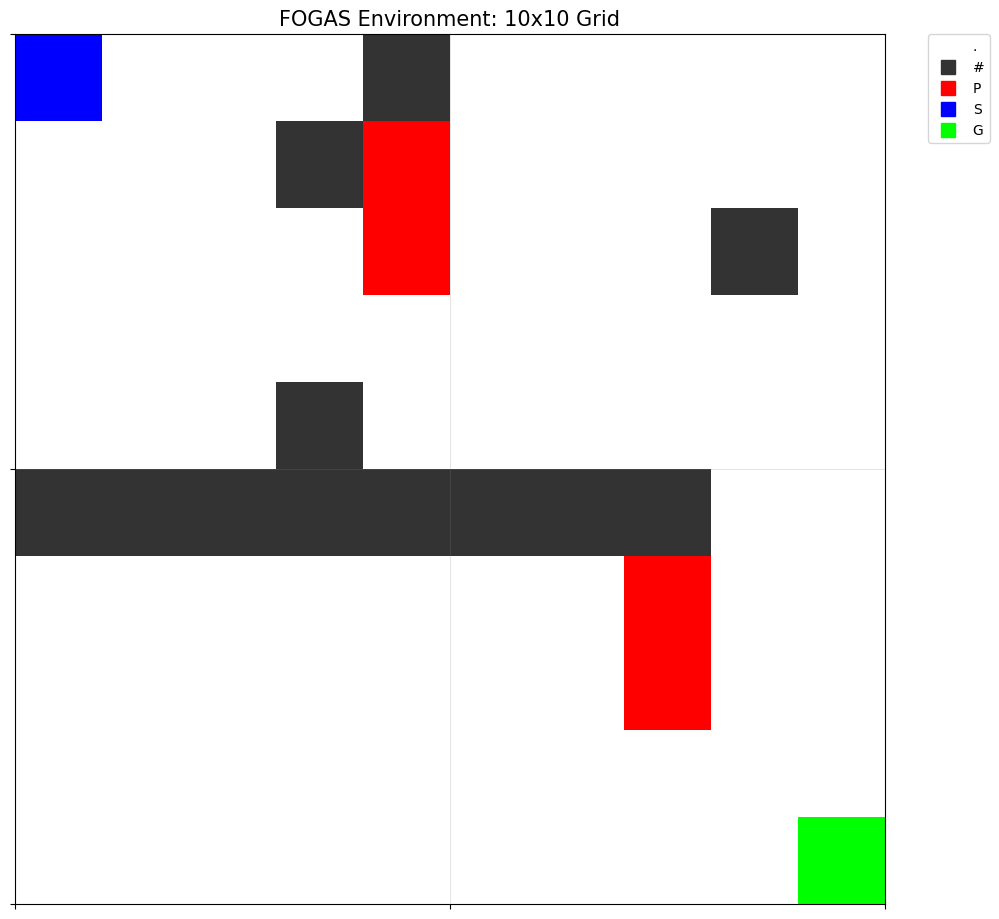

In [4]:
grid_layout = [
    "S...#.....",
    "...#P.....",
    "....P...#.",
    "..........",
    "...#......",
    "########..",
    ".......P..",
    ".......P..",
    "..........",
    ".........G"
]
# Load it as a 2D numpy array (how your environment expects it)
grid_10 = np.array([list(row) for row in grid_layout])
# To test it visually
plot_fogas_grid(grid_10)

# Linear MDP

In [5]:
def generate_mdp_regular_grid(grid_data, gamma=0.99):
    size = grid_data.shape[0]
    N = size * size
    A = 4
    
    walls = set(np.where(grid_data.flatten() == '#')[0])
    pits = set(np.where(grid_data.flatten() == 'P')[0])
    goal = np.where(grid_data.flatten() == 'G')[0][0]
    start_node = np.where(grid_data.flatten() == 'S')[0][0]

    # --- Regular Grid Center Generation ---
    # Target 50% of the total states (N)
    target_num_centers = int(N * 0.5)
    
    # Because we are making a square meshgrid, we need the "centers per side"
    # which is the square root of the target number of centers.
    centers_per_side = int(np.sqrt(target_num_centers))
    
    # Creates a meshgrid in normalized [0, 1] space
    ticks = np.linspace(0.0, 1.0, centers_per_side)
    c_x, c_y = np.meshgrid(ticks, ticks)
    centers = torch.tensor(np.column_stack([c_x.ravel(), c_y.ravel()]), dtype=torch.float64)
    
    def reward_fn(x, a):
        x_int = int(x)
        if x_int == goal: return 10.0
        if x_int in pits: return -10.0
        return -0.01

    P = torch.zeros((N * A, N), dtype=torch.float64)
    for x in range(N):
        for a in range(A):
            if x in pits or x == goal:
                P[x * A + a, x] = 1.0
                continue
            r, c = divmod(x, size)
            if a == 0: r_n, c_n = max(0, r-1), c
            elif a == 1: r_n, c_n = min(size-1, r+1), c
            elif a == 2: r_n, c_n = r, max(0, c-1)
            elif a == 3: r_n, c_n = r, min(size-1, c+1)
            next_s = r_n * size + c_n
            if next_s in walls: next_s = x
            P[x * A + a, next_s] = 1.0

    return {
        "centers": centers, "walls": walls, "pits": pits, 
        "goal": goal, "start": start_node, "reward_fn": reward_fn, 
        "P": P, "N": N, "A": A, "gamma": gamma
    }

def get_phi_state_func(centers, sigma, size, pits, goal):
    """Returns a scale-invariant phi_state function."""
    def phi_state(x):
        # Normalize coordinates based on the current grid size
        r, c = divmod(int(x), size)
        coords = torch.tensor([r / (size - 1), c / (size - 1)], dtype=torch.float64)
        
        # Calculate RBF activations
        dist_sq = torch.sum((coords - centers)**2, dim=1)
        rbf = torch.exp(-dist_sq / (2 * sigma**2))
        
        # Indicator features as per FOGAS standard practice
        is_pit = 1.0 if int(x) in pits else 0.0
        is_goal = 1.0 if int(x) == goal else 0.0
        indicators = torch.tensor([is_pit, is_goal], dtype=torch.float64)
        
        # Feature vector includes RBFs, Bias (1.0), and Indicators
        return torch.cat([rbf, torch.ones(1, dtype=torch.float64), indicators])
    return phi_state

def calculate_local_sigma(centers, k=2):
    """Computes sigma based on k-nearest neighbors for spatial precision."""
    dist_matrix = torch.cdist(centers, centers, p=2)
    topk_dists, _ = torch.topk(dist_matrix, k + 1, largest=False, dim=1)
    return torch.mean(topk_dists[:, 1])

def plot_grid_with_centers(grid_data, centers):
    size = grid_data.shape[0]
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)
    
    colors = ['#FFFFFF', '#333333', '#FF0000', '#0000FF', '#00FF00']
    cmap = mcolors.ListedColormap(colors)
    
    plt.figure(figsize=(12, 12))
    plt.imshow(numeric_grid, cmap=cmap)
    
    # Overlay Centers (Scaled back from [0,1] to [0, size-1])
    centers_scaled = centers.numpy() * (size - 1)
    plt.scatter(centers_scaled[:, 1], centers_scaled[:, 0], 
                c='blue', marker='x', s=size, label='RBF Feature Centers', alpha=0.6)
    
    plt.title(f"FOGAS Feature Allocation ({size}x{size})", fontsize=16)
    plt.legend(loc='upper right')
    plt.show()

# 10x10

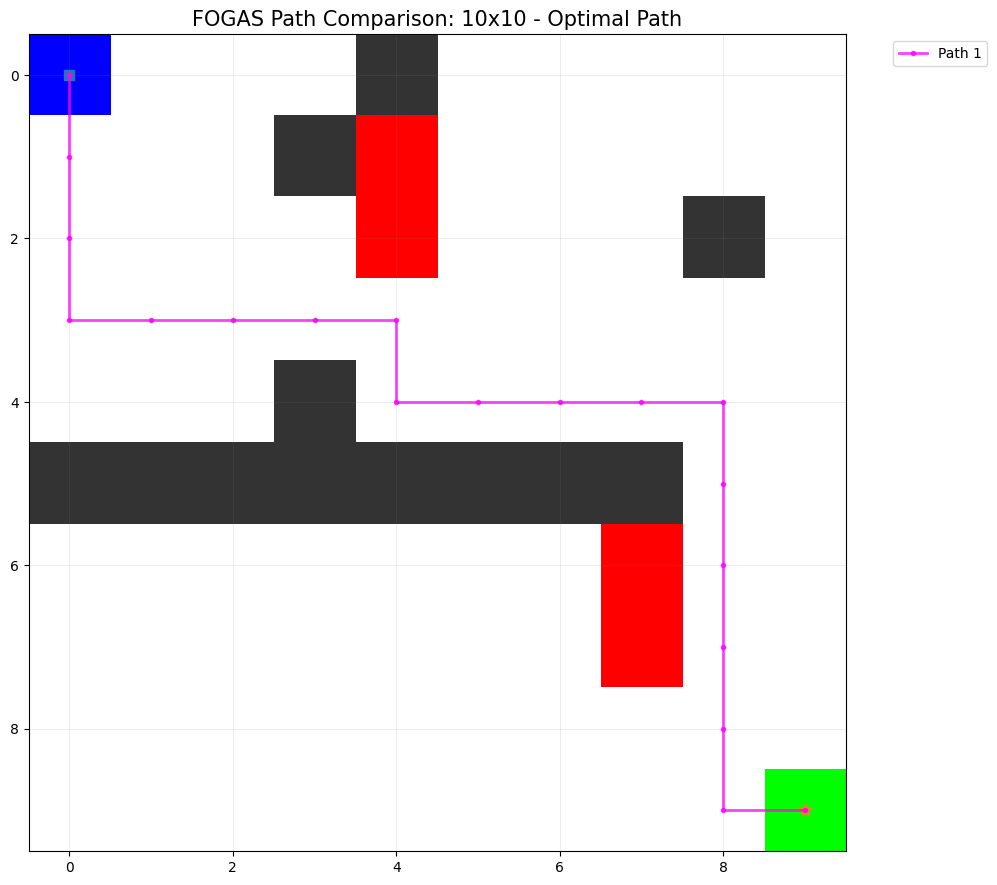

In [6]:
grid_layout = [
    "S...#.....",
    "...#P.....",
    "....P...#.",
    "..........",
    "...#......",
    "########..",
    ".......P..",
    ".......P..",
    "..........",
    ".........G"
]
# Load it as a 2D numpy array (how your environment expects it)
grid_10 = np.array([list(row) for row in grid_layout])
size = 10

# --- STEP 2: Generate MDP Components with Regular Grid ---
# We use 15 centers per side (225 total RBFs) for a 50x50 or 100x100 grid.
mdp_data = generate_mdp_regular_grid(grid_10)

# --- STEP 3: Calculate Scale-Invariant Sigma ---
# Using Local KNN Sigma (k=2) ensures RBFs overlap with neighbors
# but don't become "blurry" across walls.
centers = mdp_data["centers"]
rbf_sigma = calculate_local_sigma(centers, k=2)

# --- STEP 4: Define the Scale-Invariant Phi Functions ---
# Note: size is passed here to ensure normalization: r / (size-1)
phi_s = get_phi_state_func(
    centers, 
    rbf_sigma, 
    size, 
    mdp_data["pits"], 
    mdp_data["goal"]
)

def phi(x, a):
    """Coupled Feature Map: phi(x, a) = e_a ⊗ phi_state(x)"""
    s_feat = phi_s(x)
    A = 4
    e_a = torch.zeros(A, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

# Calculate Feature Dimension d
sample_feat = phi(0, 0)
d = int(sample_feat.shape[0])

# --- STEP 5: Create the FOGAS Solver Object ---
# (Assumes your PolicySolver class is defined as in your previous code)
states = torch.arange(size * size, dtype=torch.int64)
actions = torch.arange(4, dtype=torch.int64)

mdp = PolicySolver(
    states=states, 
    actions=actions, 
    phi=phi,
    reward_fn=mdp_data["reward_fn"], 
    gamma=mdp_data["gamma"], 
    x0=mdp_data["start"], 
    P=mdp_data["P"]
)
optimal_path = compute_optimal_path(mdp, mdp_data, size=size)
# 2. Plot the trajectory
plot_agent_paths_with_labels(grid_10, [optimal_path], title_suffix="- Optimal Path")

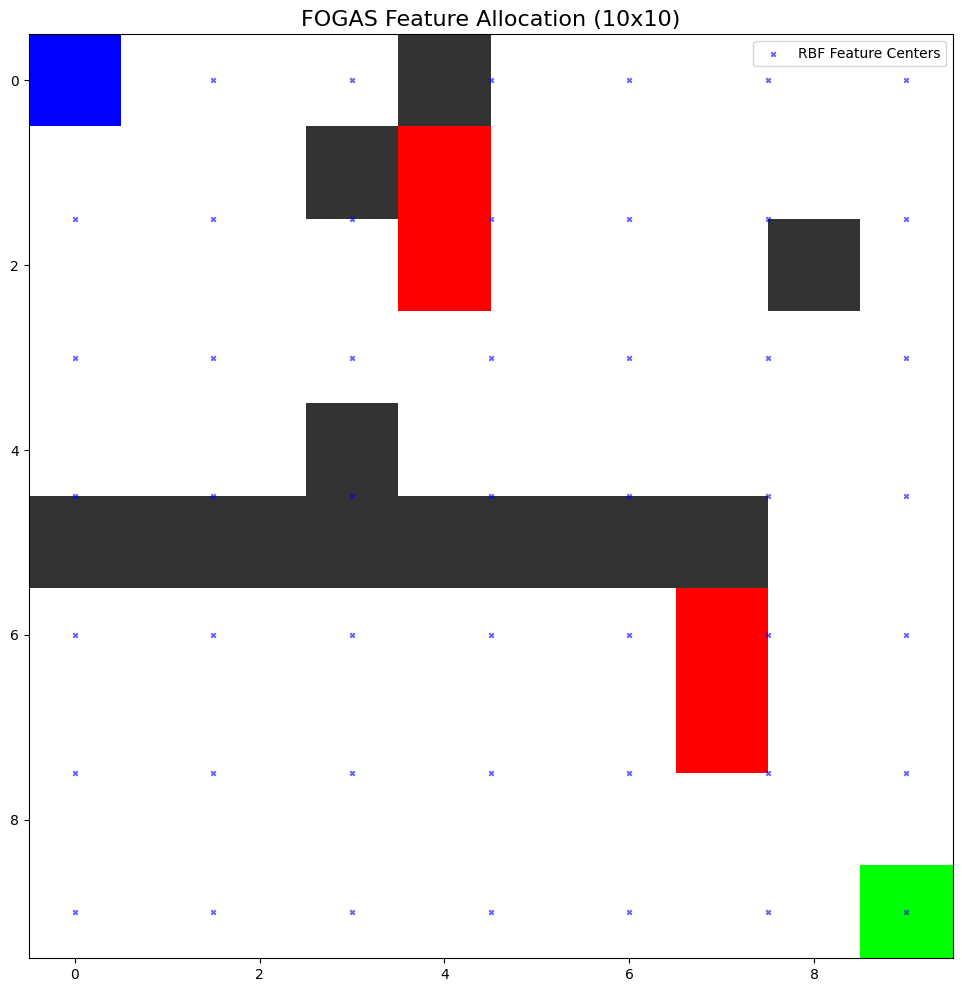

In [ ]:
plot_grid_with_centers(grid_data=grid_10, centers=centers)

### Dataset creation

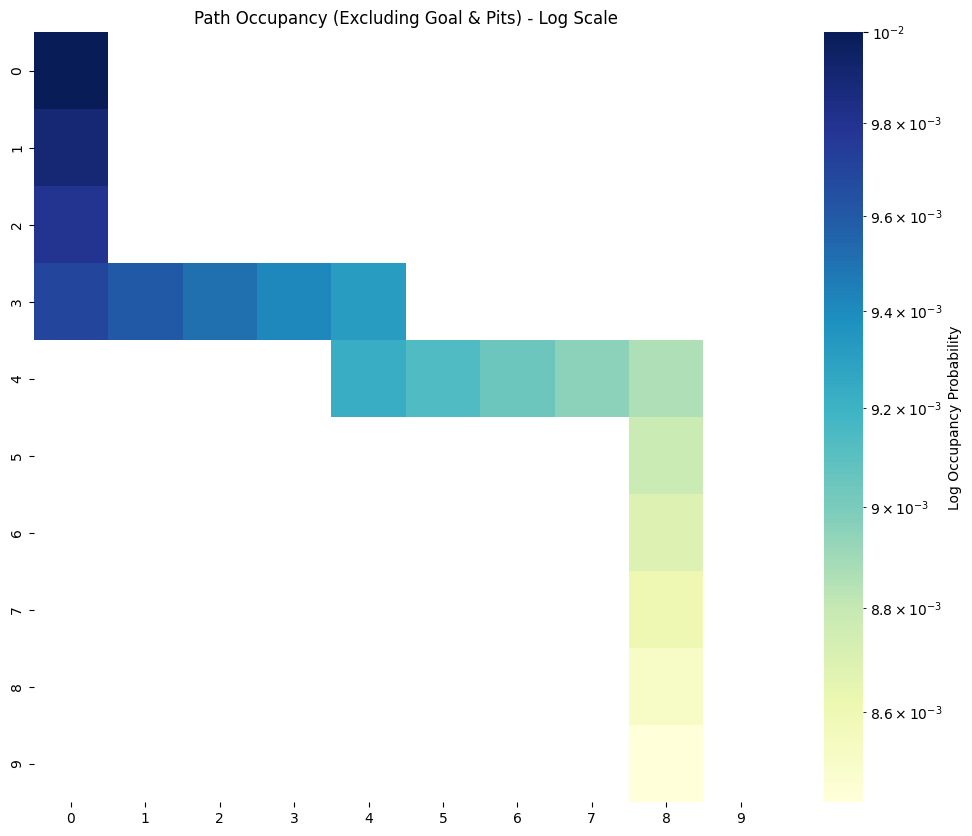

In [ ]:
# 1. Get occupancy probabilities
probs = mdp.state_mu_star.detach().cpu().numpy().copy()

# 2. Mask the Goal/Pits (Terminal States) for better visual scaling
# The goal index is usually size*size - 1
terminal_indices = list(mdp_data['pits']) + [mdp_data['goal']]
for idx in terminal_indices:
    probs[idx] = 0.0

# 3. Reshape
grid_size = size
occupancy_grid = probs.reshape(grid_size, grid_size)

# 4. Plot with Log Normalization to see small probabilities along the path
plt.figure(figsize=(12, 10))
sns.heatmap(occupancy_grid, 
            cmap="YlGnBu", 
            norm=LogNorm(vmin=probs[probs>0].min() if any(probs>0) else 1e-6, vmax=probs.max()),
            cbar_kws={'label': 'Log Occupancy Probability'})

plt.title("Path Occupancy (Excluding Goal & Pits) - Log Scale")
plt.show()


In [ ]:
reset_options = {
    'x0': 0.1, 
    'occupancy': 0.9
}

# Initialize the collector with these options
collector = EnvDataCollector(
    mdp=mdp,
    env_name="50grid",
    restricted_states=mdp_data["walls"],  # These will never be starting states
    reset_probs=reset_options,
    max_steps=200
)

# Create an epsilon-greedy pi_star (30% optimal, 70% random)
epsilon_policy = (mdp.pi_star, 0.3)

df = collector.collect_mixed_dataset_terminal_aware(
    policies=[epsilon_policy, "random"],  
    proportions=[0.8, 0.2],
    n_steps=10000,
    episode_based=True,                   
    save_path=str(DATASET_PATH),
    verbose=True,
    extra_steps=50 
)


  MIXED TERMINAL-AWARE DATASET COLLECTION SUMMARY (TORCH)
Total transitions: 10000
Total episodes: 135
Extra steps: 50

Policy Distribution:
  Policy 0:  7189 steps (71.9%) | Target: 80.0% | Episodes: 112
  Policy 1:  2811 steps (28.1%) | Target: 20.0% | Episodes: 24

✅ Mixed terminal-aware dataset saved to: /shared/home/mauro.diaz/work/FOGAS/datasets/10grid_exp.csv


In [ ]:
analyzer = DatasetAnalyzer(DATASET_PATH)

ratio = analyzer.feature_coverage_ratio(
    mdp=mdp,
    beta=1e-6,
    use_optimal_policy=True,
    verbose=True,
    return_details=True,
)


Feature Coverage Ratio Details
------------------------------
  Dataset size (n):         10000
  MDP dims (N, A, d):        (100, 4, 208)
  gamma:                    0.99
  beta (ridge):             1e-06
  policy source:            provided

  Occupancy μ_pi summary:
    sum:                    1
    min / max:              0 / 0.834514

  Feature occupancy λ_pi summary:
    ||λ||_2:                1.66147
    ||λ||_1:                5.27676
    max |λ_i|:              0.834514

  Empirical covariance Λ_n:
    diag min / mean / max:  1.04882e-06 / 0.0198363 / 0.518401
    eig min / max:          1e-06 / 1.51132
    condition number:       1.51132e+06

  Coverage ratio:           2.19567


Total states: 100
Walls: 12
Visited: 60
Non-visited non-walls: 28


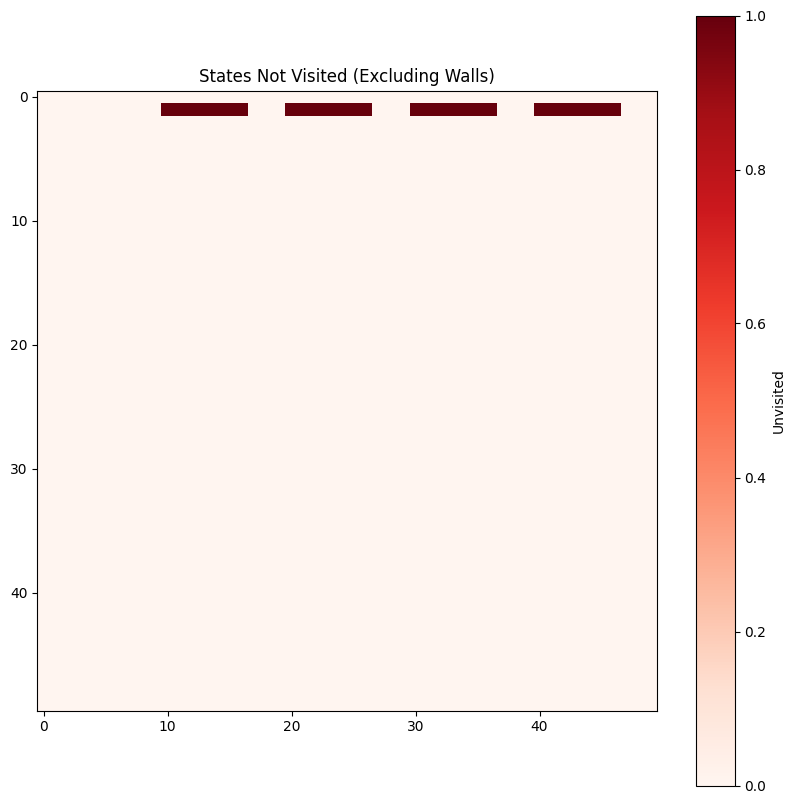

In [ ]:
# 1. Get all visited states from your collected dataset
visited_states = set(df['state'].unique())

# 2. Get the set of wall states
# Since you are in the 50x50grid notebook, mdp_data contains the wall indices
wall_states = set(mdp_data['walls'])

# 3. Calculate states that were NOT visited and are NOT walls
all_states = set(range(mdp.N))
non_visited_non_walls = all_states - visited_states - wall_states

print(f"Total states: {mdp.N}")
print(f"Walls: {len(wall_states)}")
print(f"Visited: {len(visited_states)}")
print(f"Non-visited non-walls: {len(non_visited_non_walls)}")

# Optional: Convert indices to (row, col) coordinates for the 50x50 grid
size = 50
coords = [divmod(s, size) for s in sorted(list(non_visited_non_walls))]
# print(coords[:10]) # Show first 10 missing states

# Create an empty 50x50 map (0 = visited/wall, 1 = missing)
coverage_map = np.zeros((size, size))
for s in non_visited_non_walls:
    r, c = divmod(s, size)
    coverage_map[r, c] = 1
plt.figure(figsize=(10, 10))
plt.imshow(coverage_map, cmap='Reds')
plt.title("States Not Visited (Excluding Walls)")
plt.colorbar(label="Unvisited")
plt.show()


### Solving it

[FOGASSolverVectorized] omega estimated via regression (beta_omega=1.00e-07, n=10000)

     REWARD APPROXIMATION ANALYSIS
Metric                                Value
────────────────────────────────────────────
Max |error|                        0.062983
Mean |error|                       0.004149
RMSE                               0.009642
R² (explained variance)            0.999982


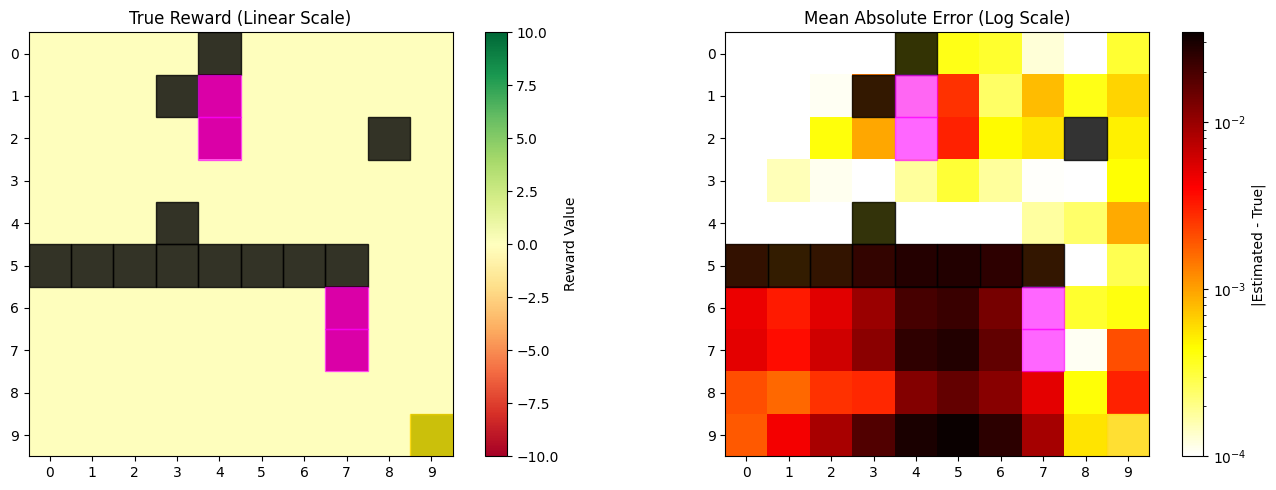

In [ ]:
solver_e = FOGASSolverVectorized(
    mdp=mdp,
    csv_path=str(DATASET_PATH),
    device=device,
    beta=1e-7,
    seed=seed)
evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(solver=solver_e,metric_callable=evaluator_e.get_metric("reward"), seed=seed)

evaluator_e.analyze_reward_approximation(
    walls=mdp_data["walls"], 
    pits=mdp_data["pits"], 
    goal=mdp_data["goal"]
    )

In [ ]:
# Run solver with best alpha and fixed rho, eta
solver_e.run(alpha=0.0001 / 2, eta=0.00002, rho=0.5, tqdm_print=True, T=10000)
evaluator_e.print_optimal_path(goal_state=mdp_data["goal"])

FOGAS: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:05<00:00, 1809.97it/s]


  OPTIMAL PATH VISUALIZATION - Learned Policy (π_FOGAS)

Initial State: 0
Goal State: 99
Discount Factor (γ): 0.99

----------------------------------------------------------------------

  Step   0 │ State: 0        │ Action: 1       │ Reward:  -0.010 │ → 10
  Step   1 │ State: 10       │ Action: 1       │ Reward:  -0.010 │ → 20
  Step   2 │ State: 20       │ Action: 1       │ Reward:  -0.010 │ → 30
  Step   3 │ State: 30       │ Action: 3       │ Reward:  -0.010 │ → 31
  Step   4 │ State: 31       │ Action: 3       │ Reward:  -0.010 │ → 32
  Step   5 │ State: 32       │ Action: 3       │ Reward:  -0.010 │ → 33
  Step   6 │ State: 33       │ Action: 3       │ Reward:  -0.010 │ → 34
  Step   7 │ State: 34       │ Action: 1       │ Reward:  -0.010 │ → 44
  Step   8 │ State: 44       │ Action: 3       │ Reward:  -0.010 │ → 45
  Step   9 │ State: 45       │ Action: 3       │ Reward:  -0.010 │ → 46
  Step  10 │ State: 46       │ Action: 3       │ Reward:  -0.010 │ → 47
  Step  11 │ State:

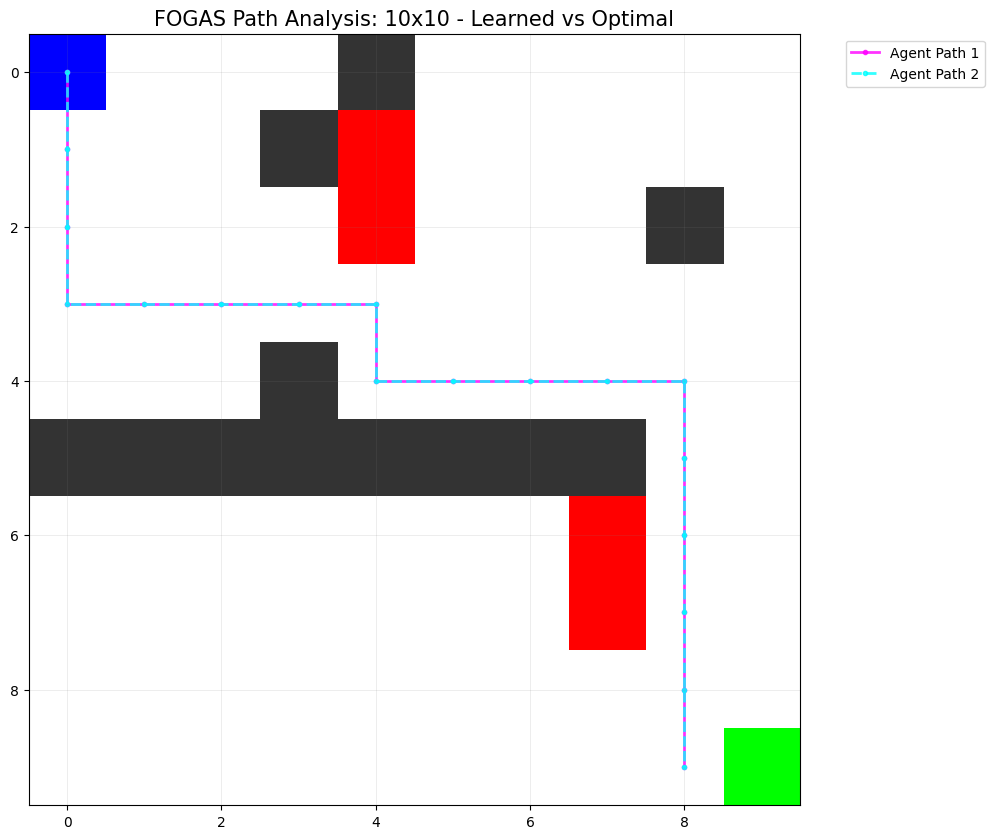

In [ ]:
traj = evaluator_e.simulate_trajectory(goal_state=mdp_data["goal"])
# 2. Extract the state indices and convert them to (row, col) coordinates
size = grid_10.shape[0]
path_coords = [divmod(step['state'], size) for step in traj]
# Simulate the optimal policy trajectory
traj_opt = evaluator_e.simulate_trajectory(pi=evaluator_e.mdp.pi_star, goal_state=mdp_data["goal"])
path_opt = [divmod(step['state'], size) for step in traj_opt]

# Plot both to see how close your learned policy is to optimal
plot_agent_paths(grid_10, [path_coords, path_opt], title_suffix="- Learned vs Optimal")

In [ ]:
evaluator_e.print_optimal_path(goal_state=mdp_data["goal"])


  OPTIMAL PATH VISUALIZATION - Learned Policy (π_FOGAS)

Initial State: 0
Goal State: 99
Discount Factor (γ): 0.99

----------------------------------------------------------------------

  Step   0 │ State: 0        │ Action: 1       │ Reward:  -0.010 │ → 10
  Step   1 │ State: 10       │ Action: 1       │ Reward:  -0.010 │ → 20
  Step   2 │ State: 20       │ Action: 1       │ Reward:  -0.010 │ → 30
  Step   3 │ State: 30       │ Action: 3       │ Reward:  -0.010 │ → 31
  Step   4 │ State: 31       │ Action: 3       │ Reward:  -0.010 │ → 32
  Step   5 │ State: 32       │ Action: 3       │ Reward:  -0.010 │ → 33
  Step   6 │ State: 33       │ Action: 3       │ Reward:  -0.010 │ → 34
  Step   7 │ State: 34       │ Action: 1       │ Reward:  -0.010 │ → 44
  Step   8 │ State: 44       │ Action: 3       │ Reward:  -0.010 │ → 45
  Step   9 │ State: 45       │ Action: 3       │ Reward:  -0.010 │ → 46
  Step  10 │ State: 46       │ Action: 3       │ Reward:  -0.010 │ → 47
  Step  11 │ State:

# 20x20

## Different $\pi^*$

In [52]:
# 1. Define base grid and scale it
grid_10 = np.array([list(row) for row in grid_layout])
grid_20 = scale_grid(grid_10, factor=2)
size_10, size_20 = grid_10.shape[0], grid_20.shape[0]

# 2. Generate MDP components freshly
mdp_data_10 = generate_mdp_regular_grid(grid_10)
mdp_data_20 = generate_mdp_regular_grid(grid_20)

# 3. Extract the ground-truth feature space
fixed_centers = mdp_data_10["centers"]
fixed_sigma = calculate_local_sigma(fixed_centers, k=2)

# 4. Explicitly redefine the 10x10 feature map to avoid stale closures
phi_s_10 = get_phi_state_func(fixed_centers, fixed_sigma, size_10, mdp_data_10["pits"], mdp_data_10["goal"])

def phi_10_fixed(x, a):
    s_feat = phi_s_10(x)
    e_a = torch.zeros(4, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

# 5. Define the 20x20 feature map using the exact same centers
phi_s_20 = get_phi_state_func(fixed_centers, fixed_sigma, size_20, mdp_data_20["pits"], mdp_data_20["goal"])

def phi_20_fixed(x, a):
    s_feat = phi_s_20(x)
    e_a = torch.zeros(4, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)
# --- STEP 7: Create the FOGAS Solver Object for 20x20 ---
# Ensure we are using the correct state and action spaces for the 20x20 grid
states_20 = torch.arange(size_20 * size_20, dtype=torch.int64)
actions_20 = torch.arange(4, dtype=torch.int64)

# Initialize the solver
mdp_20 = PolicySolver(
    states=states_20, 
    actions=actions_20, 
    phi=phi_20_fixed,          # The rigorously aligned feature map
    reward_fn=mdp_data_20["reward_fn"], 
    gamma=mdp_data_20["gamma"], 
    x0=mdp_data_20["start"], 
    P=mdp_data_20["P"],
)

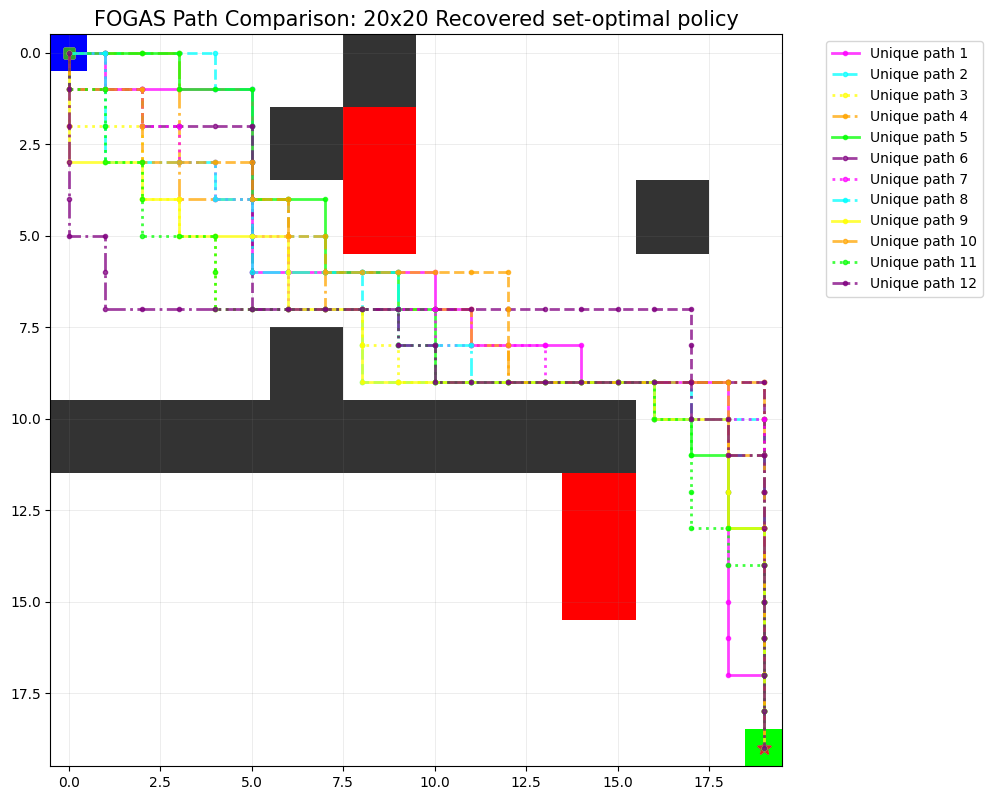

In [51]:
pi_set = mdp_20.policy_from_optimal_q(mode="set", tie_eps=1e-10)

paths, states_list, actions_list = sample_multiple_policy_paths(
    mdp=mdp_20,
    mdp_data=mdp_data_20,
    size=20,
    pi=pi_set,
    n_paths=30,
    max_steps=500,
    seed=0
)

paths_unique = sample_unique_policy_paths(
    mdp=mdp_20,
    mdp_data=mdp_data_20,
    size=20,
    pi=pi_set,
    n_samples=300,
    max_unique=12,
    max_steps=500,
    seed=0
)

labels = [f"Unique path {i+1}" for i in range(len(paths_unique))]
plot_agent_paths_with_labels(
    grid_data=grid_20,
    paths=paths_unique,
    labels=labels,
    title_suffix="Recovered set-optimal policy"
)

We build the second optimal policy:

### Dataset collection

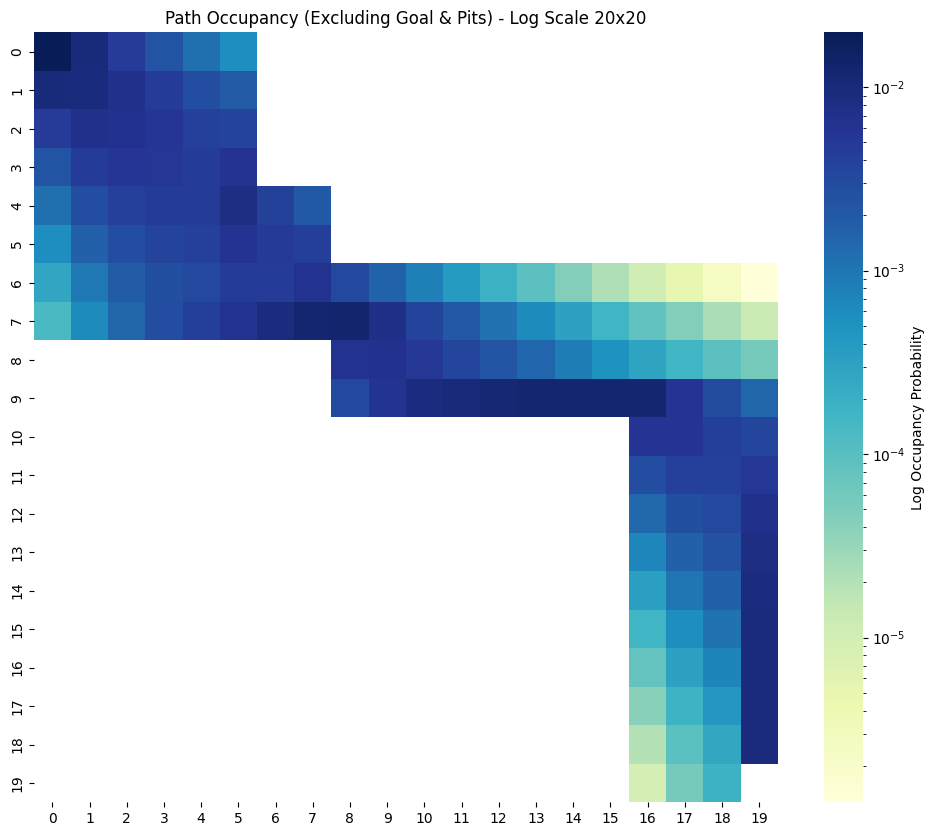

In [7]:
pi_rec = mdp_20.policy_from_optimal_q(mode="set", tie_eps=1e-10)
mu_rec = mdp_20.occupancy_measure(pi_rec)
probs20 = mu_rec.reshape(mdp_20.N, mdp_20.A).sum(dim=1).detach().cpu().numpy().copy()

# 2. Mask the Goal/Pits (Terminal States) for better visual scaling
# Uses the mdp1_data containing indices for the 100x100 grid
terminal_indices1 = list(mdp_data_20['pits']) + [mdp_data_20['goal']]
for idx in terminal_indices1:
    probs20[idx] = 0.0

# 3. Reshape using the new grid size
grid_size1 = 20
occupancy_grid1 = probs20.reshape(grid_size1, grid_size1)

# 4. Plot with Log Normalization
plt.figure(figsize=(12, 10))
sns.heatmap(
    occupancy_grid1, 
    cmap="YlGnBu", 
    norm=LogNorm(
        vmin=probs20[probs20 > 0].min() if any(probs20 > 0) else 1e-6, 
        vmax=probs20.max()
    ),
    cbar_kws={'label': 'Log Occupancy Probability'}
)

plt.title(f"Path Occupancy (Excluding Goal & Pits) - Log Scale {grid_size1}x{grid_size1}")
plt.show()


Data collection with both polcies:

In [37]:
reset_options1 = {
    'x0': 0.4, 
    'occupancy': 0.6 
}

# Initialize the collector for the 20x20 grid
collector1 = EnvDataCollector(
    mdp=mdp_20,
    env_name="20grid",                   
    restricted_states=mdp_data_20["walls"], 
    reset_probs=reset_options1,
    max_steps=100                         
)

# Behavior policy: 80% epsilon-greedy, 20% random
epsilon_policy1 = (pi_rec, 0.3)

# 3. Use it in your data collector
df1 = collector1.collect_mixed_dataset_terminal_aware(
    policies=[epsilon_policy1, "random"],  
    proportions=[1.0, 0.0], 
    n_steps=16000, 
    episode_based=True,                   
    save_path=str(DATASET_PATH1),
    verbose=True
)


  MIXED TERMINAL-AWARE DATASET COLLECTION SUMMARY (TORCH)
Total transitions: 16000
Total episodes: 355
Extra steps: 5

Policy Distribution:
  Policy 0: 16000 steps (100.0%) | Target: 100.0% | Episodes: 356
  Policy 1:     0 steps ( 0.0%) | Target:  0.0% | Episodes: 0

✅ Mixed terminal-aware dataset saved to: /shared/home/mauro.diaz/work/FOGAS/datasets/20grid.csv


In [38]:
# Initialize the analyzer with your dataset path
analyzer = DatasetAnalyzer(str(DATASET_PATH1))

# Define the states you want to check
states_to_check = [379, 359, 398]

# Get the counts
state_counts = analyzer.count_states(states_to_check)

# Print the results
print("State Frequencies in Dataset:")
for state, count in state_counts.items():
    print(f"  State {state}: {count} times")

State Frequencies in Dataset:
  State 379: 333 times
  State 359: 361 times
  State 398: 60 times


Total states (100x100): 400
Walls: 48
Visited: 172
Non-visited non-walls: 180


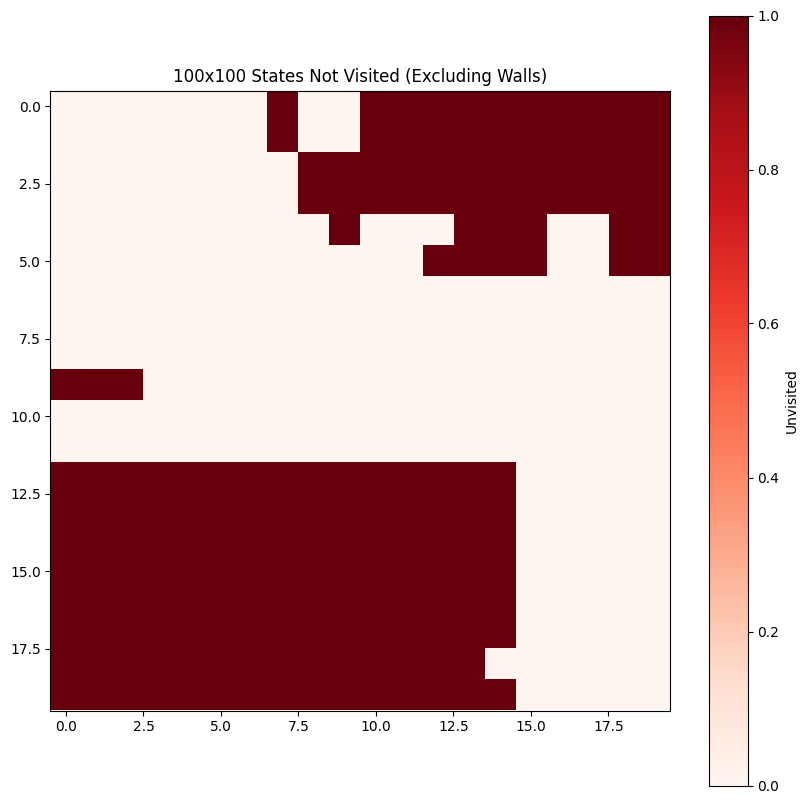

In [39]:
# 1. Get all visited states from your collected 100x100 dataset
visited_states1 = set(df1['state'].unique())

# 2. Get the set of wall states for the 100x100 grid
wall_states1 = set(mdp_data_20['walls'])

# 3. Calculate states that were NOT visited and are NOT walls
all_states1 = set(range(mdp_20.N))
non_visited_non_walls1 = all_states1 - visited_states1 - wall_states1

print(f"Total states (100x100): {mdp_20.N}")
print(f"Walls: {len(wall_states1)}")
print(f"Visited: {len(visited_states1)}")
print(f"Non-visited non-walls: {len(non_visited_non_walls1)}")

# Convert indices to (row, col) coordinates for the 100x100 grid
size1 = 20
coords1 = [divmod(s, size1) for s in sorted(list(non_visited_non_walls1))]

# Create an empty 100x100 map (0 = visited/wall, 1 = missing)
coverage_map1 = np.zeros((size1, size1))
for s in non_visited_non_walls1:
    r, c = divmod(s, size1)
    coverage_map1[r, c] = 1

plt.figure(figsize=(10, 10))
plt.imshow(coverage_map1, cmap='Reds')
plt.title(f"100x100 States Not Visited (Excluding Walls)")
plt.colorbar(label="Unvisited")
plt.show()

### Solving it

[FOGASSolverVectorized] omega estimated via regression (beta_omega=1.00e-07, n=16000)

     REWARD APPROXIMATION ANALYSIS
Metric                                Value
────────────────────────────────────────────
Max |error|                        0.013652
Mean |error|                       0.001415
RMSE                               0.002609
R² (explained variance)            0.999998

--------------------------------------------------
State  Action         r_true      r_hat      error
──────────────────────────────────────────────────
0            ↑ Up          -0.0100    -0.0099     0.0001
0            ↓ Down        -0.0100    -0.0100     0.0000
0            ← Left        -0.0100    -0.0099     0.0001
0            → Right       -0.0100    -0.0100     0.0000
1            ↑ Up          -0.0100    -0.0101    -0.0001
1            ↓ Down        -0.0100    -0.0100    -0.0000
1            ← Left        -0.0100    -0.0101    -0.0001
1            → Right       -0.0100    -0.0100    -0.0000
2  

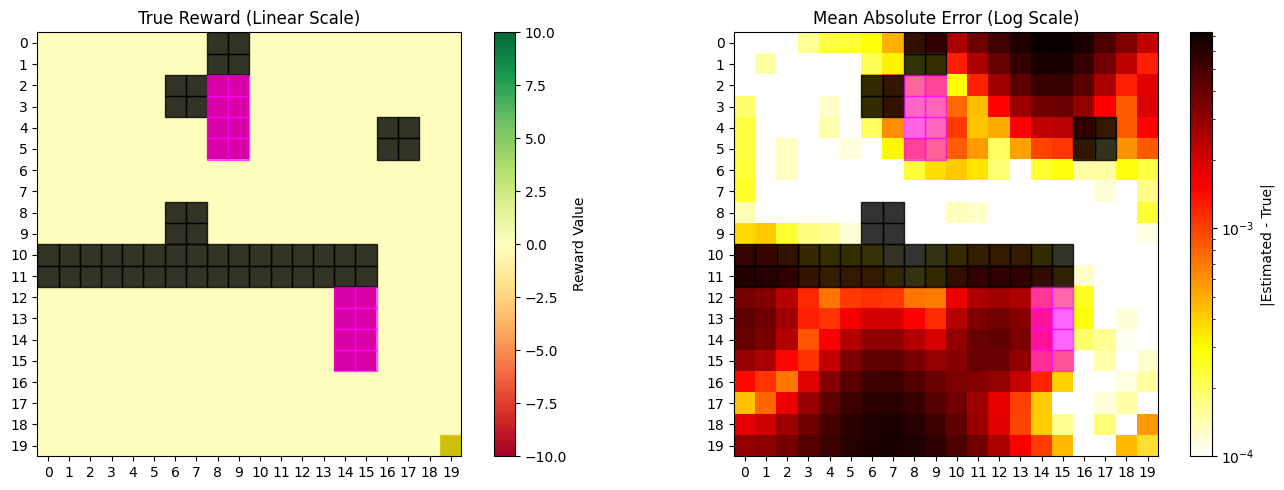

In [40]:
# Initialize the vectorized solver for the 100x100 dataset
solver1_e = FOGASSolverVectorized(
    mdp=mdp_20,
    csv_path=str(DATASET_PATH1),
    device=device,
    beta=1e-7,
    seed=seed
)

# Initialize the evaluator for the 100x100 solver
evaluator1_e = FOGASEvaluator(solver1_e)

# Initialize the hyperparameter optimizer for 100x100
optimizer1_e = FOGASHyperOptimizer(
    solver=solver1_e,
    metric_callable=evaluator1_e.get_metric("reward"), 
    seed=seed
)

# Run the reward approximation analysis on the 100x100 environment
evaluator1_e.analyze_reward_approximation(
    walls=mdp_data_20["walls"], 
    pits=mdp_data_20["pits"], 
    goal=mdp_data_20["goal"],
    print_each = True
)


In [41]:
solver1_e.run(
    alpha=0.0001,
    eta=0.00002, 
    rho=0.5, 
    tqdm_print=True, 
    T=25000
)

evaluator1_e.print_optimal_path(goal_state=mdp_data_20["goal"])

FOGAS: 100%|████████████████████████████████████████████████████████████████████████████████████████| 25000/25000 [00:16<00:00, 1549.48it/s]


  OPTIMAL PATH VISUALIZATION - Learned Policy (π_FOGAS)

Initial State: 0
Goal State: 399
Discount Factor (γ): 0.9801

----------------------------------------------------------------------

  Step   0 │ State: 0        │ Action: 1       │ Reward:  -0.010 │ → 20
  Step   1 │ State: 20       │ Action: 1       │ Reward:  -0.010 │ → 40
  Step   2 │ State: 40       │ Action: 1       │ Reward:  -0.010 │ → 60
  Step   3 │ State: 60       │ Action: 1       │ Reward:  -0.010 │ → 80
  Step   4 │ State: 80       │ Action: 1       │ Reward:  -0.010 │ → 100
  Step   5 │ State: 100      │ Action: 1       │ Reward:  -0.010 │ → 120
  Step   6 │ State: 120      │ Action: 1       │ Reward:  -0.010 │ → 140
  Step   7 │ State: 140      │ Action: 3       │ Reward:  -0.010 │ → 141
  Step   8 │ State: 141      │ Action: 3       │ Reward:  -0.010 │ → 142
  Step   9 │ State: 142      │ Action: 3       │ Reward:  -0.010 │ → 143
  Step  10 │ State: 143      │ Action: 3       │ Reward:  -0.010 │ → 144
  Step  1

In [42]:
evaluator1_e.print_policy()

  State 0: π(a=0|s=0) = 0.14  π(a=1|s=0) = 0.43  π(a=2|s=0) = 0.13  π(a=3|s=0) = 0.30  --> best action: 1
  State 1: π(a=0|s=1) = 0.05  π(a=1|s=1) = 0.36  π(a=2|s=1) = 0.02  π(a=3|s=1) = 0.57  --> best action: 3
  State 2: π(a=0|s=2) = 0.02  π(a=1|s=2) = 0.27  π(a=2|s=2) = 0.00  π(a=3|s=2) = 0.71  --> best action: 3
  State 3: π(a=0|s=3) = 0.02  π(a=1|s=3) = 0.27  π(a=2|s=3) = 0.00  π(a=3|s=3) = 0.70  --> best action: 3
  State 4: π(a=0|s=4) = 0.07  π(a=1|s=4) = 0.40  π(a=2|s=4) = 0.00  π(a=3|s=4) = 0.53  --> best action: 3
  State 5: π(a=0|s=5) = 0.25  π(a=1|s=5) = 0.50  π(a=2|s=5) = 0.02  π(a=3|s=5) = 0.23  --> best action: 1
  State 6: π(a=0|s=6) = 0.53  π(a=1|s=6) = 0.34  π(a=2|s=6) = 0.08  π(a=3|s=6) = 0.05  --> best action: 0
  State 7: π(a=0|s=7) = 0.59  π(a=1|s=7) = 0.16  π(a=2|s=7) = 0.24  π(a=3|s=7) = 0.01  --> best action: 0
  State 8: π(a=0|s=8) = 0.44  π(a=1|s=8) = 0.07  π(a=2|s=8) = 0.48  π(a=3|s=8) = 0.00  --> best action: 2
  State 9: π(a=0|s=9) = 0.27  π(a=1|s=9) = 0.0

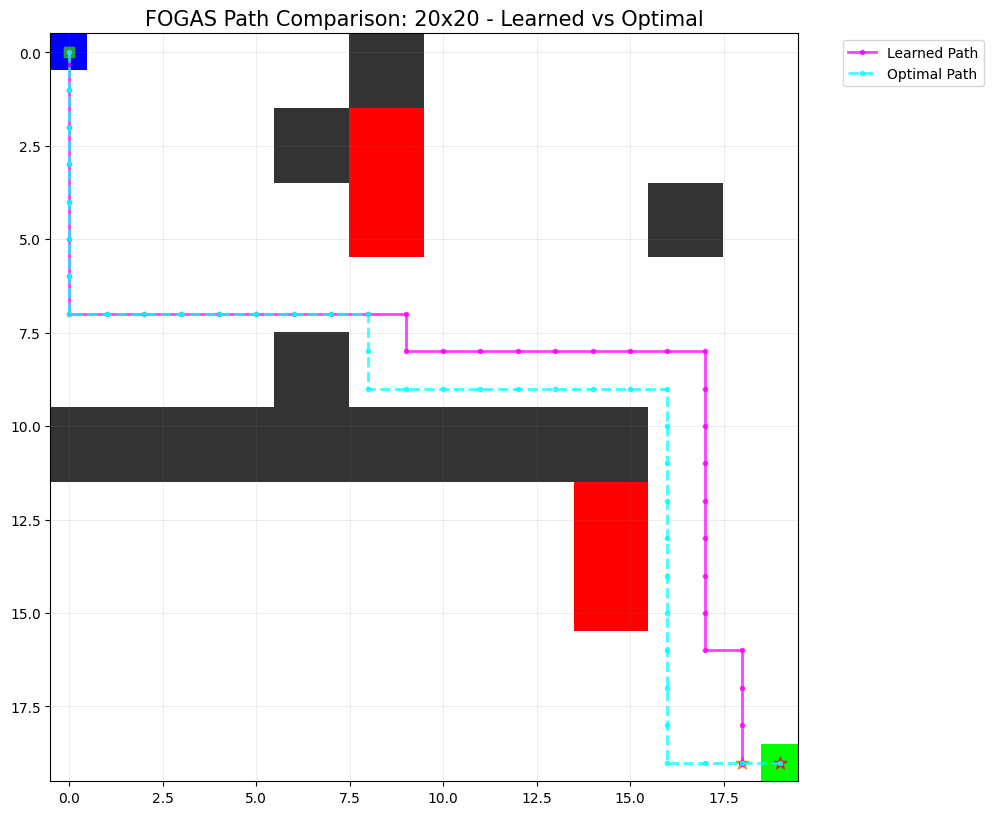

In [43]:
# 1. Simulate the trajectories
traj = evaluator1_e.simulate_trajectory(goal_state=mdp_data_20["goal"])
traj_opt = evaluator1_e.simulate_trajectory(pi=evaluator1_e.mdp.pi_star, goal_state=mdp_data_20["goal"])

size = grid_20.shape[0]

# 2. Extract path coordinates and include the final 'next_state' (the goal)
path_coords = [divmod(step['state'], size) for step in traj]
if traj:
    path_coords.append(divmod(traj[-1]['next_state'], size))

path_opt = [divmod(step['state'], size) for step in traj_opt]
if traj_opt:
    path_opt.append(divmod(traj_opt[-1]['next_state'], size))

plot_agent_paths_with_labels(
    grid_20, 
    paths=[path_coords, path_opt], 
    labels=["Learned Path", "Optimal Path"], 
    title_suffix="- Learned vs Optimal"
)

## Aggregation - same actions

In [8]:
# 1. Define base grid and scale it for aggregation
grid_10 = np.array([list(row) for row in grid_layout])
grid_20 = scale_grid_goal_block(grid_10, factor=2)
size_10, size_20 = grid_10.shape[0], grid_20.shape[0]

# 2. Generate MDP components freshly
mdp_data_10 = generate_mdp_regular_grid(grid_10)
mdp_data_20 = generate_mdp_regular_grid(grid_20)

# 3. Extract the ground-truth feature space
fixed_centers = mdp_data_10["centers"]
fixed_sigma = calculate_local_sigma(fixed_centers, k=2)

# 4. Explicitly redefine the 10x10 feature map to avoid stale closures
phi_s_10 = get_phi_state_func(fixed_centers, fixed_sigma, size_10, mdp_data_10["pits"], mdp_data_10["goal"])

def phi_10_fixed(x, a):
    s_feat = phi_s_10(x)
    e_a = torch.zeros(4, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

# 5. Define the 20x20 feature map using the exact same centers
phi_s_20 = get_phi_state_func(fixed_centers, fixed_sigma, size_20, mdp_data_20["pits"], mdp_data_20["goal"])

def phi_20_fixed(x, a):
    s_feat = phi_s_20(x)
    e_a = torch.zeros(4, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

states_20 = torch.arange(size_20 * size_20, dtype=torch.int64)
actions_20 = torch.arange(4, dtype=torch.int64)

mdp_20 = PolicySolver(
    states=states_20,
    actions=actions_20,
    phi=phi_20_fixed,
    reward_fn=mdp_data_20["reward_fn"],
    gamma=mdp_data_20["gamma"],
    x0=mdp_data_20["start"],
    P=mdp_data_20["P"],
)


#### Dataset collection

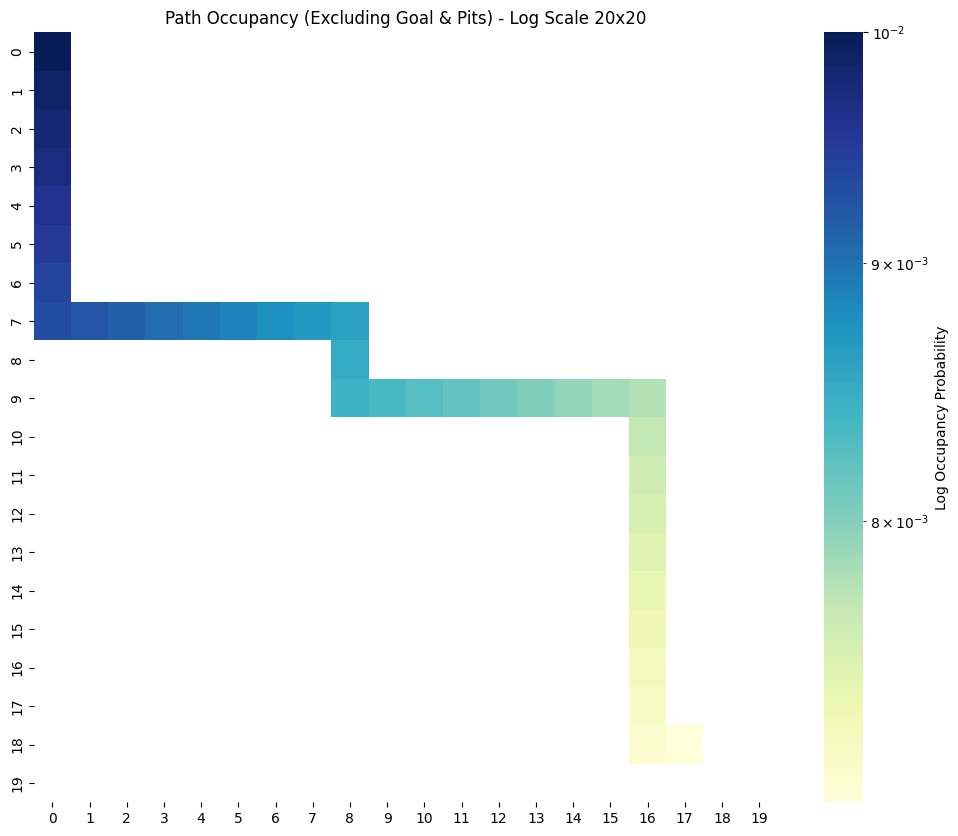

In [9]:
# 1. Get occupancy probabilities for the 100x100 MDP
probs20 = mdp_20.state_mu_star.detach().cpu().numpy().copy()

# 2. Mask the Goal/Pits (Terminal States) for better visual scaling
# Uses the mdp1_data containing indices for the 100x100 grid
terminal_indices1 = list(mdp_data_20['pits']) + [mdp_data_20['goal']]
for idx in terminal_indices1:
    probs20[idx] = 0.0

# 3. Reshape using the new grid size
grid_size1 = 20
occupancy_grid1 = probs20.reshape(grid_size1, grid_size1)

# 4. Plot with Log Normalization
plt.figure(figsize=(12, 10))
sns.heatmap(
    occupancy_grid1, 
    cmap="YlGnBu", 
    norm=LogNorm(
        vmin=probs20[probs20 > 0].min() if any(probs20 > 0) else 1e-6, 
        vmax=probs20.max()
    ),
    cbar_kws={'label': 'Log Occupancy Probability'}
)

plt.title(f"Path Occupancy (Excluding Goal & Pits) - Log Scale {grid_size1}x{grid_size1}")
plt.show()


In [10]:

MACRO_DATASET_PATH_4A = DATASET_PATH1.parent / "20_macro.csv"

In [ ]:
reset_options1 = {
    'x0': 0.0, 
    'occupancy': 1.0 
}

# Initialize the collector for the 20x20 grid
collector1 = EnvDataCollector(
    mdp=mdp_20,
    env_name="20grid",                   
    restricted_states=mdp_data_20["walls"], 
    reset_probs=reset_options1,
    max_steps=100                         
)

epsilon_policy1 = (mdp_20.pi_star, 0.3)

df_macro_4a = collector1.collect_macro_dataset_repeated_actions(
    policy=epsilon_policy1,              # or epsilon_policy_opt, or "random"
    n_macro_steps=8000,
    gamma=mdp_data_20["gamma"],         
    fine_size=20,
    coarse_size=10,
    factor=2,
    save_path=str(MACRO_DATASET_PATH_4A),
    verbose=True
)

✅ Macro dataset saved to: /shared/home/mauro.diaz/work/FOGAS/datasets/20_macro.csv
   Total macro transitions: 8000


### Macro mdp


In [11]:
size_macro = size_10
mdp_data_macro_base = mdp_data_10
phi_s_macro = phi_s_10

def phi_macro_4a(x, a):
    s_feat = phi_s_macro(x)
    e_a = torch.zeros(4, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

def make_macro_reward_fn(pits, goal, gamma_fine, step_penalty=-0.01, goal_reward=10.0, pit_reward=-10.0):
    macro_step_penalty = step_penalty + gamma_fine * step_penalty

    def reward_fn(x, a):
        x_int = int(x)
        if x_int == goal:
            return goal_reward
        if x_int in pits:
            return pit_reward
        return macro_step_penalty

    return reward_fn

macro_reward_fn_4a = make_macro_reward_fn(
    pits=mdp_data_macro_base["pits"],
    goal=mdp_data_macro_base["goal"],
    gamma_fine=mdp_data_20["gamma"],
    step_penalty=-0.01,
    goal_reward=10.0,
    pit_reward=-10.0,
)

states_macro = torch.arange(size_macro * size_macro, dtype=torch.int64)
actions_macro = torch.arange(4, dtype=torch.int64)

gamma_macro = mdp_data_20["gamma"] ** 2

mdp_macro_4a = PolicySolver(
    states=states_macro,
    actions=actions_macro,
    phi=phi_macro_4a,
    reward_fn=macro_reward_fn_4a,
    gamma=gamma_macro,
    x0=mdp_data_macro_base["start"],
    P=mdp_data_macro_base["P"],
)


### Run macro

In [19]:
solver_macro_4a = FOGASSolverVectorized(
    mdp=mdp_macro_4a,
    csv_path=str(MACRO_DATASET_PATH_4A),
    device=device,
    beta=1e-7,
    seed=seed
)

evaluator_macro_4a = FOGASEvaluator(solver_macro_4a)

optimizer_macro_4a = FOGASHyperOptimizer(
    solver=solver_macro_4a,
    metric_callable=evaluator_macro_4a.get_metric("reward"),
    seed=seed
)

[FOGASSolverVectorized] omega estimated via regression (beta_omega=1.00e-07, n=8000)


In [20]:
solver_macro_4a.run(
    alpha=0.0001,
    eta=0.00002,
    rho=0.5,
    tqdm_print=True,
    T=12000
)

evaluator_macro_4a.print_optimal_path(goal_state=mdp_data_macro_base["goal"])

FOGAS: 100%|██████████████████████████████████████████████████████████████████████████████████| 12000/12000 [00:07<00:00, 1631.09it/s]



  OPTIMAL PATH VISUALIZATION - Learned Policy (π_FOGAS)

Initial State: 0
Goal State: 99
Discount Factor (γ): 0.9801

----------------------------------------------------------------------

  Step   0 │ State: 0        │ Action: 1       │ Reward:  -0.020 │ → 10
  Step   1 │ State: 10       │ Action: 1       │ Reward:  -0.020 │ → 20
  Step   2 │ State: 20       │ Action: 1       │ Reward:  -0.020 │ → 30
  Step   3 │ State: 30       │ Action: 3       │ Reward:  -0.020 │ → 31
  Step   4 │ State: 31       │ Action: 3       │ Reward:  -0.020 │ → 32
  Step   5 │ State: 32       │ Action: 3       │ Reward:  -0.020 │ → 33
  Step   6 │ State: 33       │ Action: 3       │ Reward:  -0.020 │ → 34
  Step   7 │ State: 34       │ Action: 1       │ Reward:  -0.020 │ → 44
  Step   8 │ State: 44       │ Action: 3       │ Reward:  -0.020 │ → 45
  Step   9 │ State: 45       │ Action: 3       │ Reward:  -0.020 │ → 46
  Step  10 │ State: 46       │ Action: 3       │ Reward:  -0.020 │ → 47
  Step  11 │ Stat

### Solve policy

In [12]:
def fine_to_coarse_state(x_fine, fine_size=20, coarse_size=10, factor=2):
    """
    Map a fine-grid state index to its coarse-grid cell.
    """
    r_f, c_f = divmod(int(x_fine), fine_size)
    r_c, c_c = r_f // factor, c_f // factor
    return int(r_c * coarse_size + c_c)

In [13]:
def rollout_macro_policy_on_fine_mdp(
    pi_macro,
    mdp_fine,
    mdp_data_fine,
    fine_to_coarse_state_fn,
    max_macro_steps=100,
    deterministic=True,
):
    """
    Roll out a coarse macro policy on the fine MDP with true repeated-action semantics.

    One macro step:
      1. map fine state x_t -> coarse state g(x_t)
      2. choose macro action a ~ pi_macro[g(x_t)]
      3. apply the same fine action twice in the fine MDP
    """
    if isinstance(pi_macro, torch.Tensor):
        pi_macro_np = pi_macro.detach().cpu().numpy()
    else:
        pi_macro_np = np.asarray(pi_macro)

    x = int(mdp_data_fine["start"])
    path = [x]
    actions = []
    rewards = []
    transitions = []

    goal = int(mdp_data_fine["goal"])
    pits = set(int(p) for p in mdp_data_fine["pits"])

    for macro_t in range(max_macro_steps):
        x_coarse = int(fine_to_coarse_state_fn(x))

        if deterministic:
            a = int(np.argmax(pi_macro_np[x_coarse]))
        else:
            a = int(np.random.choice(pi_macro_np.shape[1], p=pi_macro_np[x_coarse]))

        macro_reward = 0.0
        x_curr = x
        done = False

        for k in range(2):
            row_idx = x_curr * mdp_fine.A + a

            if deterministic:
                x_next = int(torch.argmax(mdp_fine.P[row_idx]).item())
            else:
                probs = mdp_fine.P[row_idx]
                x_next = int(torch.multinomial(probs, num_samples=1).item())

            r = float(mdp_fine.r[row_idx].item())
            macro_reward += (mdp_fine.gamma ** k) * r

            path.append(x_next)
            transitions.append((x_curr, a, r, x_next))
            x_curr = x_next

        actions.append(a)
        rewards.append(macro_reward)
        x = x_curr

        if x == goal or x in pits:
            break

    return {
        "path": path,
        "actions": actions,
        "macro_rewards": rewards,
        "transitions": transitions,
    }


In [ ]:
grid_20_goal = grid_20
mdp_data_20_goal = mdp_data_20
mdp_20_goal = mdp_20

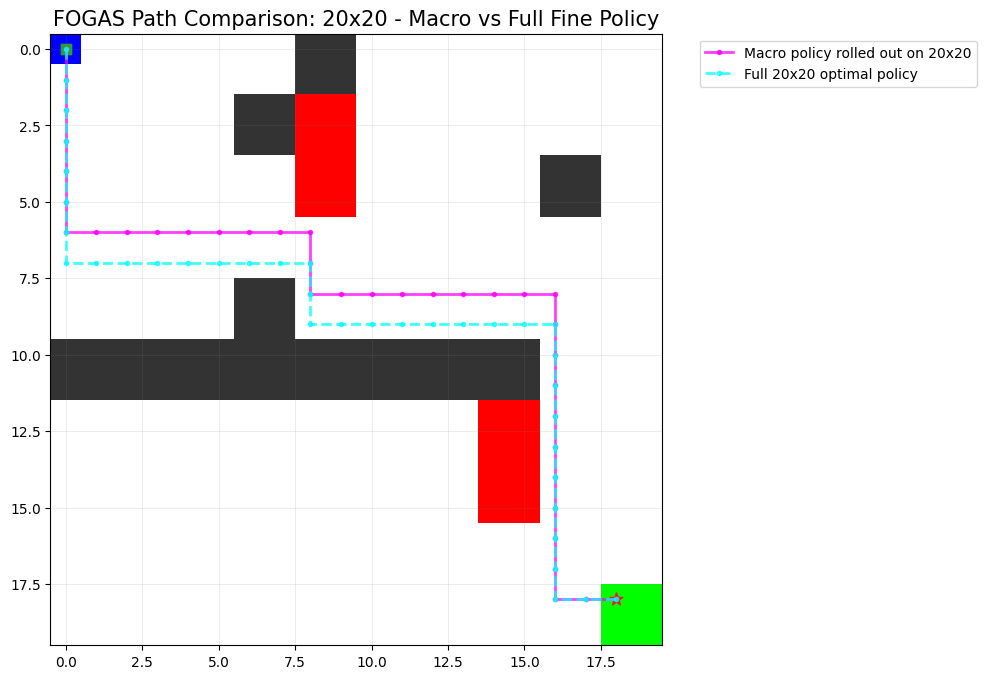

In [126]:
macro_rollout_20 = rollout_macro_policy_on_fine_mdp(
    pi_macro=mdp_macro_4a.pi_star,
    mdp_fine=mdp_20_goal,
    mdp_data_fine=mdp_data_20_goal,
    fine_to_coarse_state_fn=fine_to_coarse_state,
    max_macro_steps=100,
    deterministic=True,
)

macro_path_20 = [divmod(s, size_20) for s in macro_rollout_20["path"]]

optimal_path_20 = compute_optimal_path(mdp_20_goal, mdp_data_20_goal, size=size_20)

plot_agent_paths_with_labels(
    grid_20_goal,
    paths=[macro_path_20, optimal_path_20],
    labels=["Macro policy rolled out on 20x20", "Full 20x20 optimal policy"],
    title_suffix="- Macro vs Full Fine Policy"
)

## Aggregation - Different Actions


In [14]:
MACRO_DATASET_PATH_16A = DATASET_PATH1.parent / "20_macro_16a.csv"

reset_options1 = {
    'x0': 0.0, 
    'occupancy': 1.0 
}

# Initialize the collector for the 20x20 grid
collector1 = EnvDataCollector(
    mdp=mdp_20,
    env_name="20grid",                   
    restricted_states=mdp_data_20["walls"], 
    reset_probs=reset_options1,
    max_steps=100                         
)

epsilon_policy1 = (mdp_20.pi_star, 0.3)


df_macro_16a = collector1.collect_macro_dataset_action_pairs(
    policy=epsilon_policy1,
    n_macro_steps=16000,
    gamma=mdp_data_20["gamma"],
    fine_size=20,
    coarse_size=10,
    factor=2,
    save_path=str(MACRO_DATASET_PATH_16A),
    verbose=True,
)


✅ Macro action-pair dataset saved to: /shared/home/mauro.diaz/work/FOGAS/datasets/20_macro_16a.csv
   Total macro transitions: 16000


In [18]:
def encode_macro_action_16(a1, a2):
    return 4 * int(a1) + int(a2)
    
def decode_macro_action_16(a_macro):
    return EnvDataCollector._decode_macro_action_pair(a_macro, num_fine_actions=4)

def coarse_to_fine_block_states(x_coarse, coarse_size=10, factor=2, fine_size=20):
    """
    Return the fine states inside one coarse cell.
    """
    r_c, c_c = divmod(int(x_coarse), coarse_size)
    fine_states = []

    for dr in range(factor):
        for dc in range(factor):
            r_f = r_c * factor + dr
            c_f = c_c * factor + dc
            fine_states.append(r_f * fine_size + c_f)

    return fine_states

def build_macro_transition_matrix_16a_from_fine(
    mdp_fine,
    fine_to_coarse_state_fn,
    coarse_size=10,
    fine_size=20,
    factor=2,
    num_fine_actions=4,
):
    """
    Build analytical macro P for 16 macro actions from the fine MDP.

    Macro action a_macro encodes (a1, a2), where:
        a1 = a_macro // 4
        a2 = a_macro % 4

    For each coarse state, we average uniformly over the fine states in its 2x2 block.
    """
    num_coarse_states = coarse_size * coarse_size
    num_macro_actions = num_fine_actions * num_fine_actions

    P_macro = torch.zeros(
        (num_coarse_states * num_macro_actions, num_coarse_states),
        dtype=torch.float64
    )

    for x_c in range(num_coarse_states):
        fine_block = coarse_to_fine_block_states(
            x_c,
            coarse_size=coarse_size,
            factor=factor,
            fine_size=fine_size,
        )

        for a1 in range(num_fine_actions):
            for a2 in range(num_fine_actions):
                a_macro = encode_macro_action_16(a1, a2)
                row_idx = x_c * num_macro_actions + a_macro

                coarse_next_probs = torch.zeros(num_coarse_states, dtype=torch.float64)

                # Uniformly average over the fine states inside the coarse block
                for x_f in fine_block:
                    row1 = x_f * mdp_fine.A + a1
                    p1 = mdp_fine.P[row1]  # distribution over fine next state after a1

                    # Then apply a2 from every possible intermediate fine state
                    p2_total = torch.zeros(mdp_fine.N, dtype=torch.float64)

                    for x_mid in range(mdp_fine.N):
                        prob_mid = float(p1[x_mid].item())
                        if prob_mid == 0.0:
                            continue

                        row2 = x_mid * mdp_fine.A + a2
                        p2_total += prob_mid * mdp_fine.P[row2]

                    # Aggregate fine next-state distribution back to coarse states
                    for x_f_next in range(mdp_fine.N):
                        prob_next = float(p2_total[x_f_next].item())
                        if prob_next == 0.0:
                            continue

                        x_c_next = fine_to_coarse_state_fn(
                            x_f_next,
                            fine_size=fine_size,
                            coarse_size=coarse_size,
                            factor=factor,
                        )
                        coarse_next_probs[x_c_next] += prob_next

                # Average over the 2x2 fine states in the source block
                coarse_next_probs /= len(fine_block)

                # Numerical cleanup
                total = coarse_next_probs.sum().item()
                if total > 1e-12:
                    coarse_next_probs /= total
                else:
                    coarse_next_probs[x_c] = 1.0

                P_macro[row_idx] = coarse_next_probs

    return P_macro

In [16]:
P_macro_16a_analytic = build_macro_transition_matrix_16a_from_fine(
    mdp_fine=mdp_20,
    fine_to_coarse_state_fn=fine_to_coarse_state,
    coarse_size=10,
    fine_size=20,
    factor=2,
    num_fine_actions=4,
)

num_macro_actions_16 = 16

def phi_macro_16a(x, a):
    s_feat = phi_s_macro(x)
    e_a = torch.zeros(num_macro_actions_16, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

macro_reward_fn_16a = make_macro_reward_fn(
    pits=mdp_data_macro_base["pits"],
    goal=mdp_data_macro_base["goal"],
    gamma_fine=mdp_data_20["gamma"],
    step_penalty=-0.01,
    goal_reward=10.0,
    pit_reward=-10.0,
)

actions_macro_16a = torch.arange(num_macro_actions_16, dtype=torch.int64)

mdp_macro_16a = PolicySolver(
    states=states_macro,
    actions=actions_macro_16a,
    phi=phi_macro_16a,
    reward_fn=macro_reward_fn_16a,
    gamma=gamma_macro,
    x0=mdp_data_macro_base["start"],
    P=P_macro_16a_analytic,
)

In [23]:
def rollout_macro_action_pair_policy_on_fine_mdp(
    pi_macro,
    mdp_fine,
    mdp_data_fine,
    fine_to_coarse_state_fn,
    max_macro_steps=100,
    deterministic=True,
):
    if isinstance(pi_macro, torch.Tensor):
        pi_macro_np = pi_macro.detach().cpu().numpy()
    else:
        pi_macro_np = np.asarray(pi_macro)

    x = int(mdp_data_fine["start"])
    path = [x]
    actions = []
    rewards = []
    transitions = []

    goal = int(mdp_data_fine["goal"])
    pits = set(int(p) for p in mdp_data_fine["pits"])

    for _ in range(max_macro_steps):
        x_coarse = int(fine_to_coarse_state_fn(x))

        if deterministic:
            a_macro = int(np.argmax(pi_macro_np[x_coarse]))
        else:
            a_macro = int(np.random.choice(pi_macro_np.shape[1], p=pi_macro_np[x_coarse]))

        a1, a2 = decode_macro_action_16(a_macro)
        x_curr = x
        macro_reward = 0.0

        for k, a in enumerate((a1, a2)):
            row_idx = x_curr * mdp_fine.A + a

            if deterministic:
                x_next = int(torch.argmax(mdp_fine.P[row_idx]).item())
            else:
                probs = mdp_fine.P[row_idx]
                x_next = int(torch.multinomial(probs, num_samples=1).item())

            r = float(mdp_fine.r[row_idx].item())
            macro_reward += (mdp_fine.gamma ** k) * r
            path.append(x_next)
            transitions.append((x_curr, a, r, x_next))
            x_curr = x_next

        actions.append((a_macro, a1, a2))
        rewards.append(macro_reward)
        x = x_curr

        if x == goal or x in pits:
            break

    return {
        "path": path,
        "actions": actions,
        "macro_rewards": rewards,
        "transitions": transitions,
    }

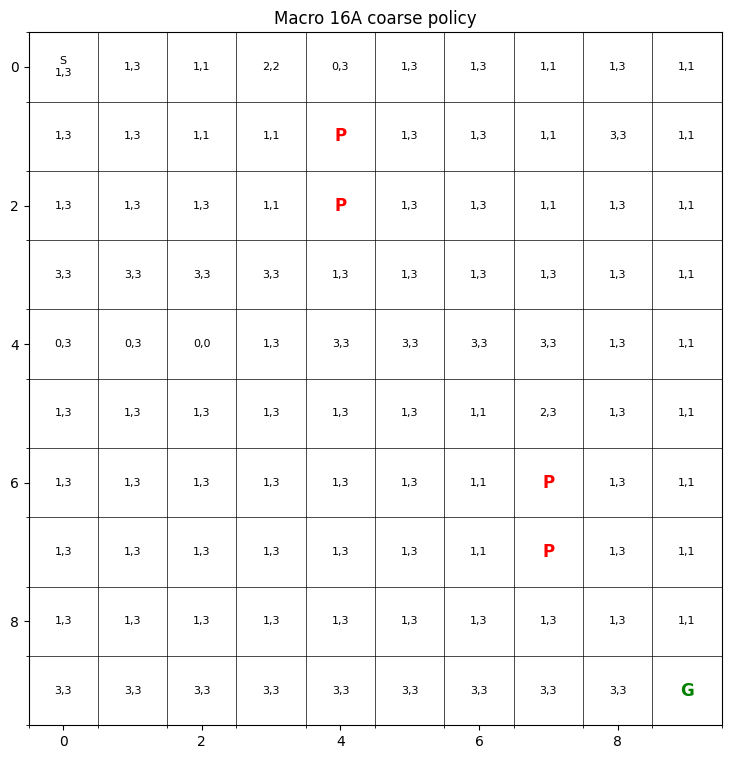

In [24]:
def plot_macro_policy_text(mdp, mdp_data, size):
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(np.zeros((size, size)), cmap="Greys", vmin=0, vmax=1)

    pits = set(mdp_data["pits"])
    goal = mdp_data["goal"]
    start = mdp_data["start"]

    for s in range(size * size):
        r, c = divmod(s, size)

        if s in pits:
            ax.text(c, r, "P", ha="center", va="center", color="red", fontsize=12, fontweight="bold")
            continue
        if s == goal:
            ax.text(c, r, "G", ha="center", va="center", color="green", fontsize=12, fontweight="bold")
            continue

        a = torch.argmax(mdp.pi_star[s]).item()
        a1, a2 = decode_macro_action_16(a)
        label = f"{a1},{a2}"
        if s == start:
            label = "S\n" + label

        ax.text(c, r, label, ha="center", va="center", color="black", fontsize=8)

    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)
    ax.grid(which="minor", color="black", linewidth=0.5)
    ax.set_title("Macro 16A coarse policy")
    plt.show()

plot_macro_policy_text(mdp_macro_16a, mdp_data_macro_base, size_macro)


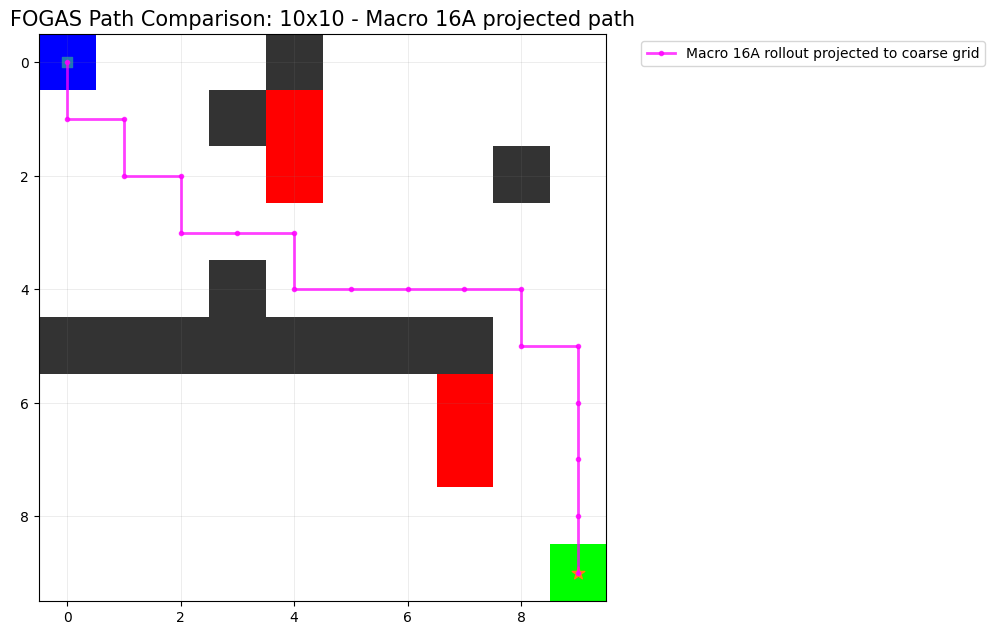

In [30]:
macro_rollout_16a = rollout_macro_action_pair_policy_on_fine_mdp(
    pi_macro=mdp_macro_16a.pi_star,
    mdp_fine=mdp_20,
    mdp_data_fine=mdp_data_20,
    fine_to_coarse_state_fn=fine_to_coarse_state,
    max_macro_steps=100,
    deterministic=True,
)

coarse_states_visited = [
    fine_to_coarse_state(s, fine_size=20, coarse_size=10, factor=2)
    for s in macro_rollout_16a["path"]
]

macro_path_10_from_fine = []
for s in coarse_states_visited:
    rc = divmod(s, size_macro)
    if not macro_path_10_from_fine or macro_path_10_from_fine[-1] != rc:
        macro_path_10_from_fine.append(rc)

plot_agent_paths_with_labels(
    grid_10,
    paths=[macro_path_10_from_fine],
    labels=["Macro 16A rollout projected to coarse grid"],
    title_suffix="- Macro 16A projected path",
)

In [39]:
solver_macro_16a = FOGASSolverVectorized(
    mdp=mdp_macro_16a,
    csv_path=str(MACRO_DATASET_PATH_16A),
    device=device,
    beta=1e-7,
    seed=seed,
)

evaluator_macro_16a = FOGASEvaluator(solver_macro_16a)

solver_macro_16a.run(
    alpha=0.0001,
    eta=0.00002,
    rho=0.5,
    tqdm_print=True,
    T=20000,
)


[FOGASSolverVectorized] omega estimated via regression (beta_omega=1.00e-07, n=16000)


FOGAS: 100%|█████████████████████████████████████████████| 20000/20000 [01:07<00:00, 296.28it/s]


tensor([[1.5117e-02, 5.9109e-02, 1.4079e-02,  ..., 9.0530e-02, 2.3956e-02,
         1.0784e-02],
        [1.9493e-03, 9.2475e-03, 3.0153e-03,  ..., 2.3751e-02, 6.2271e-03,
         9.3092e-03],
        [1.5562e-02, 1.9621e-02, 4.6915e-02,  ..., 4.2646e-02, 2.7624e-02,
         1.6338e-02],
        ...,
        [1.5450e-02, 6.5918e-02, 3.2789e-02,  ..., 6.1676e-02, 1.0161e-01,
         2.1488e-03],
        [8.6217e-03, 7.0252e-02, 7.7628e-03,  ..., 3.8289e-02, 8.0162e-02,
         1.7217e-07],
        [9.6226e-02, 3.3258e-02, 7.1994e-02,  ..., 2.4595e-02, 3.9190e-02,
         5.0044e-03]], device='cuda:0', dtype=torch.float64)

Learned best macro action at start: 5 decoded as (1, 1)


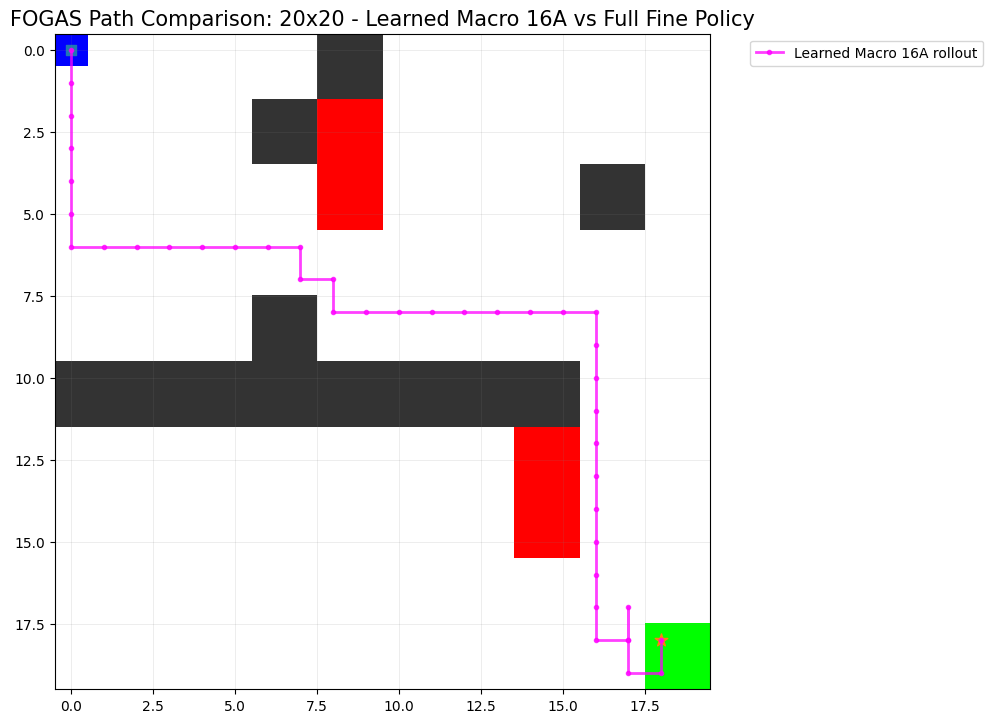

In [40]:
pi_learned_16a = solver_macro_16a.pi.detach().cpu()

start_state = mdp_data_macro_base["start"]
best_a_learned = torch.argmax(pi_learned_16a[start_state]).item()
print("Learned best macro action at start:", best_a_learned, "decoded as", decode_macro_action_16(best_a_learned))

macro_rollout_16a_learned = rollout_macro_action_pair_policy_on_fine_mdp(
    pi_macro=pi_learned_16a,
    mdp_fine=mdp_20,
    mdp_data_fine=mdp_data_20,
    fine_to_coarse_state_fn=fine_to_coarse_state,
    max_macro_steps=100,
    deterministic=True,
)

macro_path_16a_learned_20 = [divmod(s, size_20) for s in macro_rollout_16a_learned["path"]]

plot_agent_paths_with_labels(
    grid_20,
    paths=[macro_path_16a_learned_20],#, optimal_path_20],
    labels=["Learned Macro 16A rollout", "Full 20x20 optimal policy"],
    title_suffix="- Learned Macro 16A vs Full Fine Policy",
)

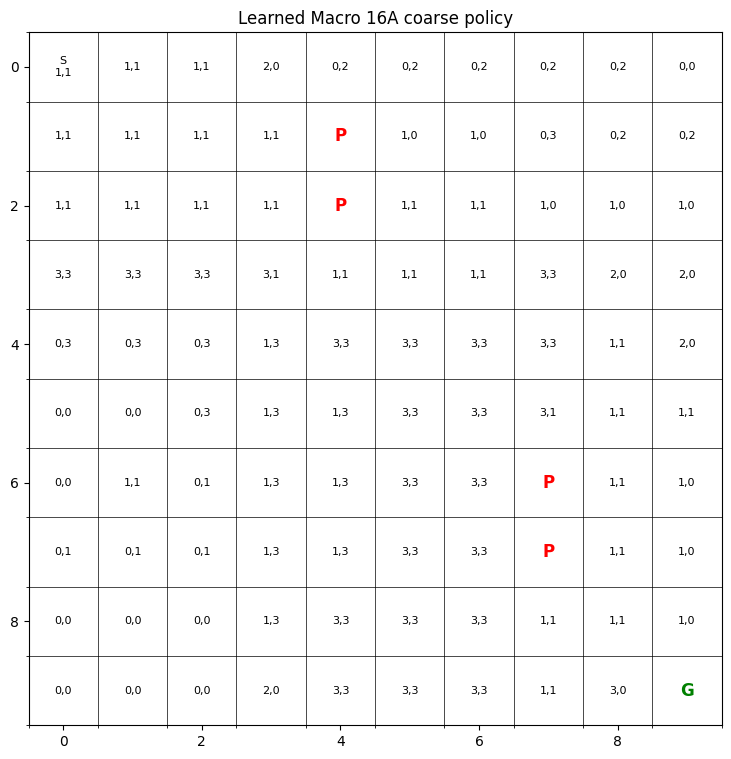

In [41]:
def plot_macro_policy_text_from_pi(pi_macro, mdp_data, size, title="Learned Macro 16A policy"):
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(np.zeros((size, size)), cmap="Greys", vmin=0, vmax=1)

    pits = set(mdp_data["pits"])
    goal = mdp_data["goal"]
    start = mdp_data["start"]

    for s in range(size * size):
        r, c = divmod(s, size)

        if s in pits:
            ax.text(c, r, "P", ha="center", va="center", color="red", fontsize=12, fontweight="bold")
            continue
        if s == goal:
            ax.text(c, r, "G", ha="center", va="center", color="green", fontsize=12, fontweight="bold")
            continue

        a = torch.argmax(pi_macro[s]).item()
        a1, a2 = decode_macro_action_16(a)
        label = f"{a1},{a2}"
        if s == start:
            label = "S\n" + label

        ax.text(c, r, label, ha="center", va="center", color="black", fontsize=8)

    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)
    ax.grid(which="minor", color="black", linewidth=0.5)
    ax.set_title(title)
    plt.show()

plot_macro_policy_text_from_pi(
    solver_macro_16a.pi.detach().cpu(),
    mdp_data_macro_base,
    size_macro,
    title="Learned Macro 16A coarse policy",
)
